In [1]:
!pip install shap tensorflow scikit-learn pandas numpy matplotlib

## Import Labraries

In [31]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## Load Dataset

In [34]:
# Load your dataset
df = pd.read_csv("nano_toxicity.csv")

print(df.head())
print(df.columns)

     NPs  coresize  hydrosize  surfcharge  surfarea    Ec  Expotime  dosage  \
0  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   0.001   
1  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   0.010   
2  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   0.100   
3  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   1.000   
4  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   5.000   

      e  NOxygen     class  
0  1.61        3  nonToxic  
1  1.61        3  nonToxic  
2  1.61        3  nonToxic  
3  1.61        3  nonToxic  
4  1.61        3  nonToxic  
Index(['NPs', 'coresize', 'hydrosize', 'surfcharge', 'surfarea', 'Ec',
       'Expotime', 'dosage', 'e', 'NOxygen', 'class'],
      dtype='object')


## Define Features & Target

In [35]:
X = df.drop(["class", "NPs"], axis=1)  # change column name if needed
y = df["class"]

In [36]:
print(df.dtypes)

NPs            object
coresize      float64
hydrosize     float64
surfcharge    float64
surfarea      float64
Ec            float64
Expotime        int64
dosage        float64
e             float64
NOxygen         int64
class          object
dtype: object


In [37]:
print(X.dtypes)

coresize      float64
hydrosize     float64
surfcharge    float64
surfarea      float64
Ec            float64
Expotime        int64
dosage        float64
e             float64
NOxygen         int64
dtype: object


In [38]:
# Separate target
y = df["class"]

# Drop target
X = df.drop("class", axis=1)

# Convert categorical → numeric
X = pd.get_dummies(X)

# FORCE numeric conversion (critical)
X = X.apply(pd.to_numeric, errors='coerce')

# Replace infinite values (important edge case)
import numpy as np
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.fillna(X.mean())

In [39]:
print(X.dtypes.unique())

[dtype('float64') dtype('int64') dtype('bool')]


In [40]:
X = X.values
y = y.values

## Preprocessing

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
print(type(y))
print(y[:5])

<class 'numpy.ndarray'>
['nonToxic' 'nonToxic' 'nonToxic' 'nonToxic' 'nonToxic']


In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

## Build ANN Model

In [90]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

C:\Users\RIZLY AZHAR\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [91]:
print(y[:10])
print(type(y[0]))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
<class 'numpy.float32'>


In [92]:
y = y.astype("float32")

In [93]:
# Target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df["class"])
y = y.astype("float32")

# Features
X = df.drop("class", axis=1)
X = X.drop("NPs", axis=1)

# Encode categorical
# X = pd.get_dummies(X)

# Convert to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Handle inf/nan
import numpy as np
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# Convert to numpy
X = X.values

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
X.shape

(881, 9)

In [95]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

C:\Users\RIZLY AZHAR\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train Model

In [96]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6377 - loss: 0.6461 - val_accuracy: 0.8156 - val_loss: 0.5654
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8259 - loss: 0.5068 - val_accuracy: 0.8085 - val_loss: 0.4590
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8597 - loss: 0.3889 - val_accuracy: 0.8298 - val_loss: 0.4179
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8721 - loss: 0.3304 - val_accuracy: 0.8723 - val_loss: 0.3655
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9023 - loss: 0.2849 - val_accuracy: 0.8794 - val_loss: 0.3361
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9254 - loss: 0.2448 - val_accuracy: 0.8723 - val_loss: 0.3001
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9094 - loss: 0.2447 - val_accuracy: 0.8723 - val_loss: 0.2667
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9218 - loss: 0.2173 - val_accuracy: 0.9007 - 

## Final Evaluation

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy: 0.9717514124293786
Precision: 1.0
Recall: 0.9404761904761905
F1 Score: 0.9693251533742331

Classification Report:

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97        93
         1.0       1.00      0.94      0.97        84

    accuracy                           0.97       177
   macro avg       0.97      0.97      0.97       177
weighted avg       0.97      0.97      0.97       177



## Graphs

## Accuracy + Loss

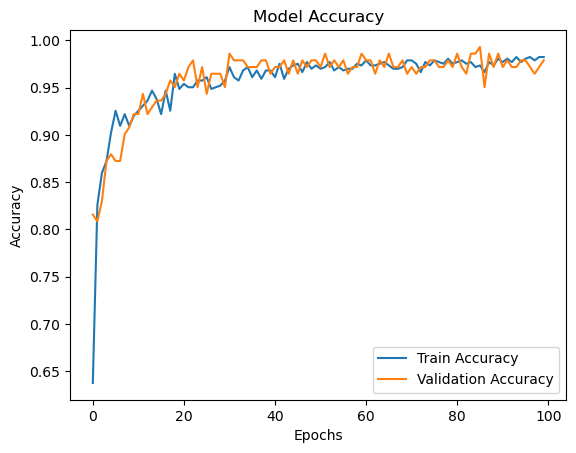

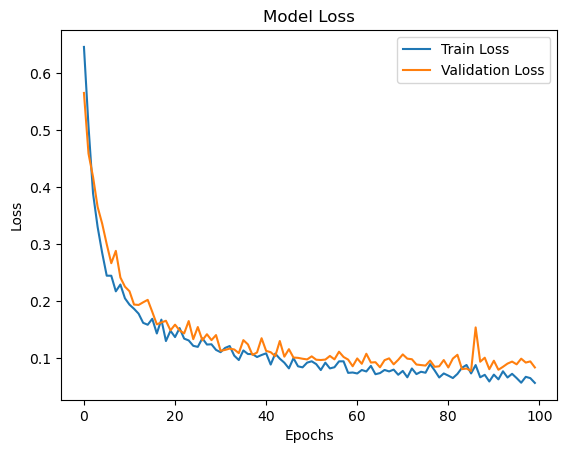

In [98]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.savefig("Model Accuracy.png")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Model Loss")
plt.savefig("Model Loss.png")
plt.show()

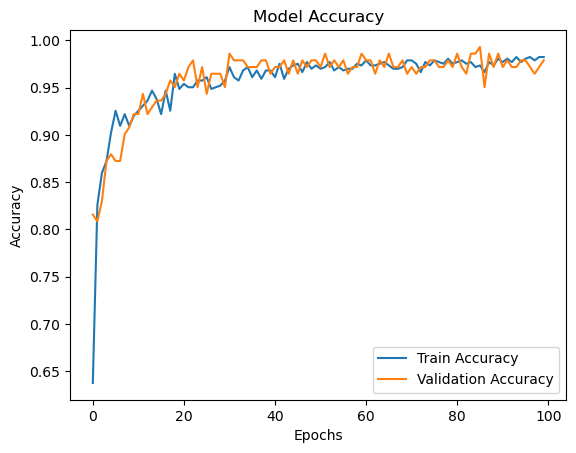

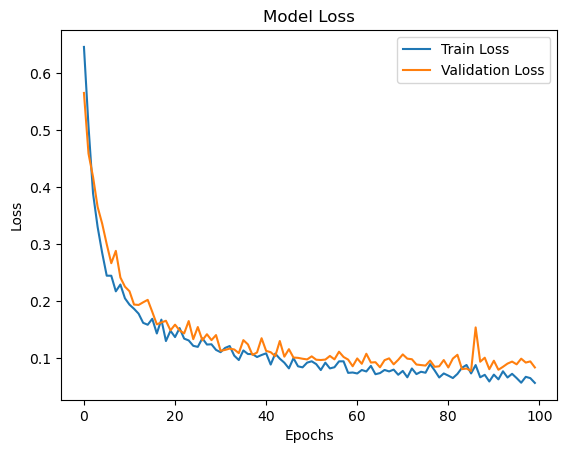

In [99]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.savefig("Model Accuracy.png")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Model Loss")
plt.savefig("Model Loss.png")
plt.show()

## Confusion Matrix

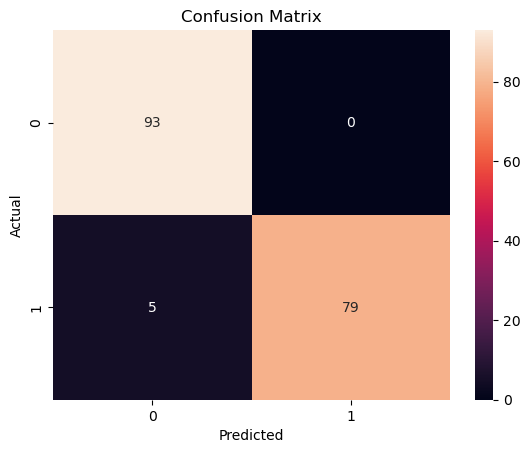

In [103]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Confusion Matrix.png")
plt.show()

## ROC Curve

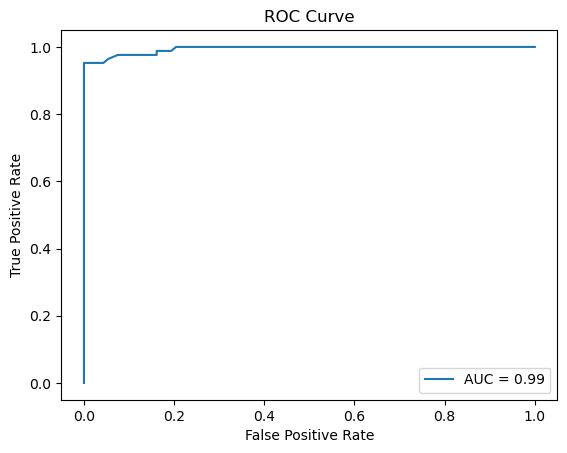

In [104]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.savefig("ROC Curve.png")
plt.legend()
plt.show()

In [64]:
X_test.shape

(177, 14)

## SHAP

In [105]:
import shap

# Use small sample for speed
X_sample = X_train[:100]

explainer = shap.KernelExplainer(model.predict, X_sample)

shap_values = explainer.shap_values(X_test[:50])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 644us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step
1/1 ━━

## SHAP Summary

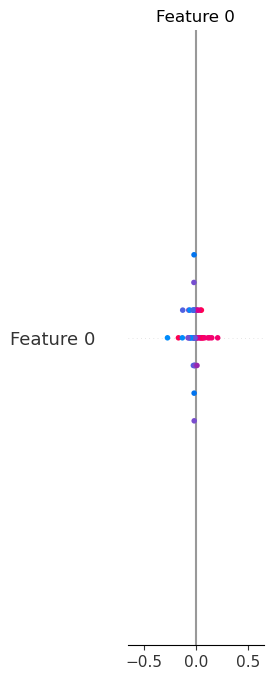

In [106]:
shap.summary_plot(shap_values, X_test[:50])

## Feature Importance

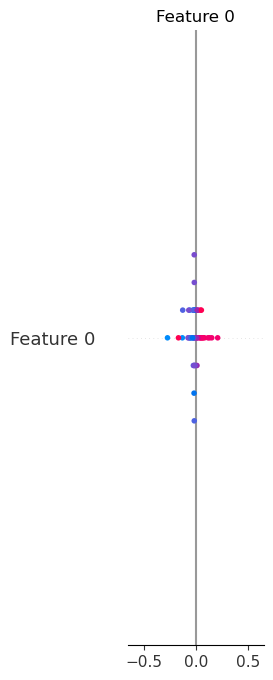

In [107]:
shap.summary_plot(shap_values, X_test[:50], plot_type="bar")

In [108]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9717514124293786
Precision: 1.0
Recall: 0.9404761904761905
F1 Score: 0.9693251533742331


In [109]:
print(confusion_matrix(y_test, y_pred))

[[93  0]
 [ 5 79]]


In [110]:
print(roc_auc)

0.9943676395289299


In [102]:
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler

# Assuming you already used scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save training data for Applicability Domain
np.save("X_train.npy", X_train)

In [100]:
model.save("nano_model.h5")

In [101]:
model.save('my_model.keras')

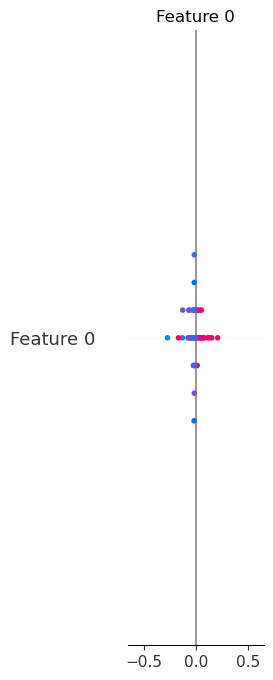

In [112]:
shap.summary_plot(shap_values, X_test[ :50], plot_type="bar", show=False)

plt.savefig("shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()